In [48]:
!pip install pyarabic transformers accelerate -q

In [50]:
import json
import random
import torch
import numpy as np
import pandas as pd

# ── Global reproducibility seeds ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# ─────────────────────────────────────────────────────────────────────────────

PATH = '/kaggle/input/datasets/farahlatrache/iadd-nlp/IADD.json'
with open(PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(df.shape)
print(df.dtypes)
print(df.head(3))


(135804, 4)
Sentence      object
Region        object
DataSource    object
Country       object
dtype: object
                                            Sentence Region DataSource Country
0   : وش فيك تسألني إذا كنت غالي؟  غالي وتسوى من ...    GLF       DART      NA
1  روان بن حسين مستحيل ما ادز شي بسناب  حتى لو ما...    GLF       DART      NA
2   : ما نسيتك بالدعا والأرض جفاف، وشلون أبنساك و...    GLF       DART      NA


In [51]:
print("=== Region distribution ===")
print(df['Region'].value_counts())

print("\n=== Total exact duplicate sentences ===")
print(f"Duplicate rows: {df.duplicated(subset='Sentence').sum():,}")

print("\n=== Sentences with conflicting Region labels ===")
conflict = df.groupby('Sentence')['Region'].nunique()
print(f"Sentences appearing with 2+ different Regions: {(conflict > 1).sum():,}")

=== Region distribution ===
Region
LEV        87573
MGH        33996
GLF         6682
EGY         4837
general     2500
IRQ          216
Name: count, dtype: int64

=== Total exact duplicate sentences ===
Duplicate rows: 9,415

=== Sentences with conflicting Region labels ===
Sentences appearing with 2+ different Regions: 324


In [52]:
import re
import pyarabic.araby as araby

# Merge IRQ into GLF (too few samples, linguistically close)
df['Region'] = df['Region'].replace('IRQ', 'GLF')
print("After merging IRQ into GLF:")
print(df['Region'].value_counts())

# Drop conflicting labels
conflict_sents = df.groupby('Sentence')['Region'].nunique()
conflicting    = conflict_sents[conflict_sents > 1].index
print(f"\nDropping {len(conflicting):,} conflicting sentences...")
df = df[~df['Sentence'].isin(conflicting)].copy()
df = df.drop_duplicates(subset='Sentence', keep='first').reset_index(drop=True)

def clean_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'^\s*:\s*', '', text)               # leading ' : ' artifact
    text = re.sub(r'http\S+|www\.\S+', '', text)       # URLs
    text = re.sub(r'@\w+', '', text)                   # @mentions
    text = re.sub(r'#\w+', '', text)                   # #hashtags
    text = araby.strip_tashkeel(text)                  # diacritics
    text = re.sub(r'[\u0623\u0625\u0622]', '\u0627', text)  # Alef variants → ا
    text = re.sub(r'\u0649', '\u064a', text)            # Yeh normalisation
    text = re.sub(r'\u0629', '\u0647', text)            # Teh Marbuta → ه
    text = araby.strip_tatweel(text)                   # tatweel
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)    # non-Arabic chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['Sentence'].apply(clean_arabic)
df['word_count'] = df['text_clean'].str.split().str.len()

# Remove empties and document-length outliers
df = df[
    (df['text_clean'].str.strip().str.len() > 0) &
    (df['word_count'] <= 500)
].reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(df['Region'].value_counts())
print(f"Imbalance ratio (max/min): {df['Region'].value_counts().max() / df['Region'].value_counts().min():.1f}x")

After merging IRQ into GLF:
Region
LEV        87573
MGH        33996
GLF         6898
EGY         4837
general     2500
Name: count, dtype: int64

Dropping 324 conflicting sentences...

Final shape: (120225, 6)
Region
LEV        84291
MGH        22145
GLF         6827
EGY         4547
general     2415
Name: count, dtype: int64
Imbalance ratio (max/min): 34.9x


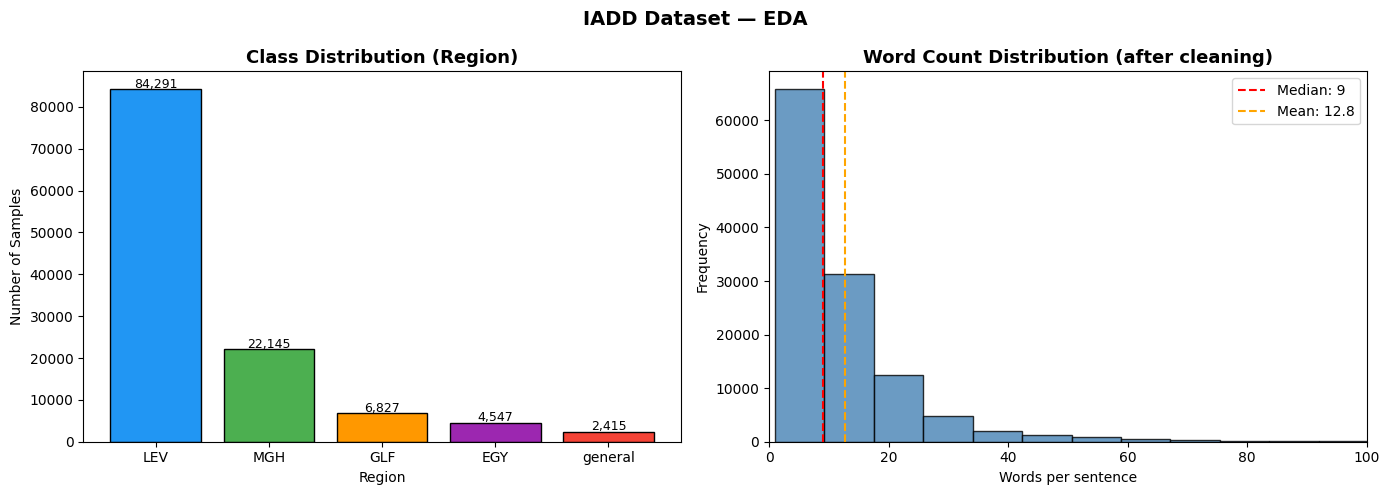

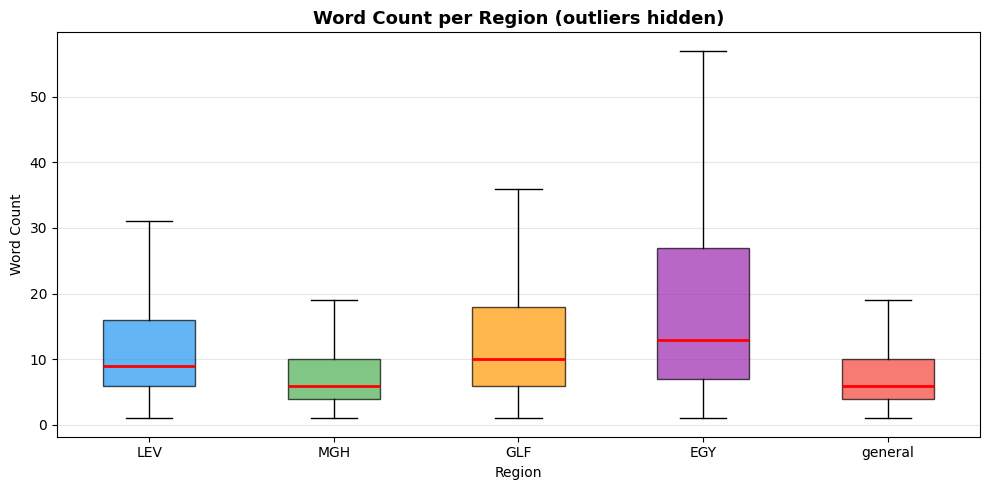

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Region'].value_counts()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#f44336']
axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='black')
axes[0].set_title('Class Distribution (Region)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Number of Samples')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 300, f'{val:,}', ha='center', fontsize=9)

axes[1].hist(df['word_count'], bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f"Median: {df['word_count'].median():.0f}")
axes[1].axvline(df['word_count'].mean(), color='orange', linestyle='--',
                label=f"Mean: {df['word_count'].mean():.1f}")
axes[1].set_title('Word Count Distribution (after cleaning)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Words per sentence')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 100)
axes[1].legend()

plt.suptitle('IADD Dataset — EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-region word-count boxplot
fig, ax = plt.subplots(figsize=(10, 5))
region_order = ['LEV', 'MGH', 'GLF', 'EGY', 'general']
data_per_class = [df[df['Region'] == r]['word_count'].values for r in region_order]
bp = ax.boxplot(data_per_class, tick_labels=region_order, patch_artist=True,
                showfliers=False, medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Word Count per Region (outliers hidden)', fontweight='bold', fontsize=13)
ax.set_xlabel('Region'); ax.set_ylabel('Word Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
#  1. Small batch generation (20 at a time) — prevents repetition collapse
#  2. Fuzzy near-duplicate filtering via rapidfuzz (threshold=88)
#  3. Stronger prompt with diversity constraints
# ═══════════════════════════════════════════════════════════════════════════════
import os, time, re
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM

# Install rapidfuzz if not already available
try:
    from rapidfuzz import fuzz
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz', '-q'])
    from rapidfuzz import fuzz

SYNTHETIC_PATH = '/kaggle/working/synthetic_data.csv'
N_PER_CLASS    = 170
BATCH_SIZE_GEN = 20   # small batches prevent repetition collapse

# ── Seed examples used in the few-shot prompt ───────────────────────────────
FEW_SHOT = {
    'EGY': [
        'يعني انت شايف ان اللي حصل ده عادي يعني؟',
        'بقولك ايه تعالى ننزل نجيب حاجة ناكلها',
        'هو انت ليه متعصب كده من الصبح؟',
        'والله الموضوع ده ملوش اي لازمة خالص',
        'مش قادر ابطل ضحك على اللي عمله امبارح',
        'انا كنت مستنيك من بدري مجتش ليه',
        'سيبك من الكلام ده وركز في اللي جاي',
        'الدنيا حر اوي النهارده ومفيش هوا خالص'
    ],
    'GLF': [
        'والله ما توقعت انه يسوي كذا ابداً',
        'شلونك اليوم؟ عساك بخير يا الغالي',
        'ترى الموضوع صار له فترة وما حد تكلم',
        'ودي اطلع بس الجو حر بشكل مو طبيعي',
        'ليش كل شوي تغير رايك بدون سبب؟',
        'ما فهمت عليك ممكن تعيد الكلام مرة ثانية',
        'ابغى اخلص الشغل واروح البيت بسرعه',
        'هالشي صراحة ضايقني وايد من البارح'
    ],
    'general': [
        'يعد التعليم من اهم العوامل التي تساهم في تقدم المجتمعات',
        'يحرص كثير من الناس على ممارسة الرياضة للحفاظ على صحتهم',
        'تساهم التكنولوجيا الحديثة في تسهيل الحياة اليومية بشكل كبير',
        'تعتبر القراءة وسيلة فعالة لتنمية المعرفة والثقافة',
        'يسعى الانسان دائما الى تطوير مهاراته وتحقيق اهدافه',
        'يجب احترام آراء الآخرين حتى في حالات الاختلاف',
        'تلعب وسائل التواصل الاجتماعي دورا مهما في نقل المعلومات',
        'تساعد الاعمال التطوعية في تعزيز روح التعاون بين افراد المجتمع'
    ]
}


# ── FIX 2: Fuzzy near-duplicate filter ──────────────────────────────────────
def is_too_similar(sentence: str, existing: list, threshold: int = 88) -> bool:
    """Return True if sentence is too similar to any existing one."""
    for ex in existing:
        if fuzz.ratio(sentence, ex) > threshold:
            return True
    return False


# ── Load Qwen2.5-3B-Instruct once ───────────────────────────────────────────
_QWEN_MODEL_NAME = 'Qwen/Qwen2.5-3B-Instruct'
print(f"Loading {_QWEN_MODEL_NAME} ...")
qwen_tokenizer = AutoTokenizer.from_pretrained(_QWEN_MODEL_NAME)
qwen_model = AutoModelForCausalLM.from_pretrained(
    _QWEN_MODEL_NAME,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map='auto'
)
print(f"✅ Qwen model loaded on {next(qwen_model.parameters()).device}")


def generate_via_llm(api_key: str, region: str, n: int) -> list:
    """Generate hard dialect examples via Qwen2.5-3B-Instruct.
    Uses small batches (BATCH_SIZE_GEN) and fuzzy deduplication.
    """
    region_desc = {
        'EGY':     'Egyptian Arabic dialect (Masri). Use Egyptian-specific vocabulary '
                   'like ايه، مش، كده، عايز، ازيك but make some sentences feel '
                   'ambiguous — almost like MSA.',
        'GLF':     'Gulf Arabic dialect (Khaleeji). Use Gulf-specific words like '
                   'وايد، تراه، ابغى، مو، شو but mix with cross-dialectal vocabulary '
                   'to make them challenging.',
        'general': 'Modern Standard Arabic (MSA / Fusha). Write in formal Arabic but '
                   'include vocabulary that also appears in dialects, making them '
                   'hard to distinguish.'
    }[region]

    examples_text = '\n'.join(f'- {e}' for e in FEW_SHOT[region])

    def _single_call(batch_n):
        """Generate one small batch of sentences via Qwen."""
        batch_prompt = (
            f'You are an expert in Arabic dialectology. Generate {batch_n} short Arabic '
            f'sentences (8-20 words each) in {region_desc}\n\n'
            f'Rules:\n'
            f'1. One sentence per line, numbered.\n'
            f'2. Arabic script ONLY — no transliteration, no English.\n'
            f'3. Make them natural, conversational, and DIFFICULT to classify correctly.\n'
            f'4. Vary the topics: daily life, emotions, food, work, social media.\n'
            f'5. Avoid repeating sentence structures.\n'
            f'6. Avoid repeating vocabulary across sentences.\n'
            f'7. Use diverse sentence openings — no two sentences should start the same way.\n'
            f'8. Mix questions, statements, emotions, and opinions.\n'
            f'9. Do NOT repeat or paraphrase the example sentences below.\n'
            f'10. Generate linguistically diverse samples.\n\n'
            f'Example sentences (do NOT copy these):\n{examples_text}\n\n'
            f'Generate {batch_n} NEW and DIFFERENT sentences:'
        )
        msgs = [
            {'role': 'system', 'content': 'You are an expert in Arabic dialectology. '
             'Always generate maximally diverse and linguistically varied sentences.'},
            {'role': 'user', 'content': batch_prompt}
        ]
        text = qwen_tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True
        )
        inputs = qwen_tokenizer([text], return_tensors='pt').to(qwen_model.device)
        with torch.no_grad():
            output_ids = qwen_model.generate(
                **inputs,
                max_new_tokens=800,   # smaller since batches are smaller now
                do_sample=True,
                temperature=0.9,      # slightly higher for more diversity
                top_p=0.95
            )
        generated_ids = [
            output_ids[i][len(inputs.input_ids[i]):] for i in range(len(output_ids))
        ]
        raw_text = qwen_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
        result = []
        for line in raw_text.strip().split('\n'):
            line = re.sub(r'^\d+[.)\-]\s*', '', line.strip()).strip()
            if line and len(line) > 5:
                result.append(line)
        return result

    # Small batches + fuzzy dedup
    collected = []
    seen_list = []   # keep as list for fuzzy comparison
    max_attempts = 20   # more attempts since batches are smaller
    attempt = 0
    while len(collected) < n and attempt < max_attempts:
        attempt += 1
        batch = _single_call(BATCH_SIZE_GEN)   # FIX 1: always 20, not n
        added_this_attempt = 0
        for s in batch:
            # fuzzy check instead of exact set membership
            if not is_too_similar(s, seen_list):
                seen_list.append(s)
                collected.append(s)
                added_this_attempt += 1
                if len(collected) >= n:
                    break
        print(f"    attempt {attempt}: got {len(batch)} raw → "
              f"+{added_this_attempt} unique → total: {len(collected)}/{n}")

    return collected[:n]


def heuristic_augment(source_df: pd.DataFrame, region: str, n: int) -> list:
    """
    Fallback: word-swap + synonym substitution on existing sentences.
    Simple but reproducible augmentation when no LLM is available.
    """
    import random
    random.seed(42 + abs(hash(region)) % 1000)

    SYNONYMS = {
        'EGY':     [('مش','ماهو'),('كده','هكذا'),('عايز','اريد'),
                    ('ايه','ما'),('دلوقتي','الان'),('اوضة','غرفه')],
        'GLF':     [('وايد','كثير'),('مو','مش'),('ابد','اصلا'),
                    ('تراه','انظر'),('ابغى','اريد'),('زين','حسن')],
        'general': [('يجب','ينبغي'),('لذلك','لهذا'),('ايضا','كذلك'),
                    ('كبير','ضخم'),('سريع','عاجل'),('مهم','ضروري')]
    }

    pool = source_df[source_df['Region'] == region]['text_clean'].tolist()
    subs = SYNONYMS.get(region, [])
    generated = set()
    attempts  = 0

    while len(generated) < n and attempts < n * 10:
        base = random.choice(pool)
        aug  = base
        random.shuffle(subs)
        for orig, repl in subs[:2]:
            if orig in aug:
                aug = aug.replace(orig, repl, 1)
        words = aug.split()
        if len(words) > 3:
            i = random.randint(0, len(words) - 2)
            words[i], words[i+1] = words[i+1], words[i]
            aug = ' '.join(words)
        if aug != base and aug not in generated:
            generated.add(aug)
        attempts += 1

    return list(generated)


# ── Load or generate ─────────────────────────────────────────────────────────
if os.path.exists(SYNTHETIC_PATH):
    synth_df = pd.read_csv(SYNTHETIC_PATH)
    print(f"Loaded existing synthetic data: {len(synth_df)} rows")
    print(synth_df['Region'].value_counts())
else:
    api_key = ''  # Not needed — using local Qwen2.5-3B-Instruct
    method  = 'Qwen2.5-3B-Instruct (few-shot, small-batch, fuzzy-dedup)'
    print(f"Generating synthetic data via {method}...")

    rows = []
    for region in ['EGY', 'GLF', 'general']:
        try:
            sentences = generate_via_llm(api_key, region, N_PER_CLASS)
            time.sleep(1)
        except Exception as e:
            print(f"  Qwen failed for {region} ({e}), using heuristic")
            sentences = heuristic_augment(df, region, N_PER_CLASS)

        for sent in sentences:
            rows.append({'Sentence': sent, 'Region': region,
                         'DataSource': 'SYNTHETIC', 'Country': 'NA',
                         'is_synthetic': True})
        print(f"  {region}: {len(sentences)} examples generated")

    synth_df = pd.DataFrame(rows)
    synth_df['text_clean'] = synth_df['Sentence'].apply(clean_arabic)
    synth_df['word_count'] = synth_df['text_clean'].str.split().str.len()
    synth_df = synth_df[synth_df['text_clean'].str.strip().str.len() > 0].reset_index(drop=True)
    synth_df.to_csv(SYNTHETIC_PATH, index=False)
    print(f"\nSaved {len(synth_df)} synthetic rows")
    print(synth_df['Region'].value_counts())

print("\n=== Sample synthetic sentences ===")
for region in ['EGY', 'GLF', 'general']:
    sample = synth_df[synth_df['Region'] == region]['text_clean'].iloc[0]
    print(f"  [{region}] {sample}")

Loading Qwen/Qwen2.5-3B-Instruct ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

✅ Qwen model loaded on cuda:0
Loaded existing synthetic data: 510 rows
Region
EGY        170
GLF        170
general    170
Name: count, dtype: int64

=== Sample synthetic sentences ===
  [EGY] هيبقي اليوم ملل عايز تروح البحر
  [GLF] انا وايد ابغي اشتري حلوي للبنات
  [general] ان صحه الانسان هي القلب الدائم لكل جهود المدربين في مجال الصحه العامه


In [55]:
# AFTER the original data is split, so val/test sets remain 100% original.

df['is_synthetic'] = False
synth_df['is_synthetic'] = True

print("Synthetic data ready for train-only injection:")
print(synth_df['Region'].value_counts())
print(f"Total synthetic rows: {len(synth_df):,}")


Synthetic data ready for train-only injection:
Region
EGY        170
GLF        170
general    170
Name: count, dtype: int64
Total synthetic rows: 510


In [56]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

le = LabelEncoder()
# Fit on original (non-augmented) data so synthetic labels never bleed into val/test
df['label'] = le.fit_transform(df['Region'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Split ORIGINAL data first, inject synthetic into train only ────
train_df, temp_df = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

# Apply the fitted label encoder to synthetic df, then concat into train only
synth_df['label'] = le.transform(synth_df['Region'])
shared_cols = ['Sentence', 'Region', 'DataSource', 'Country',
               'text_clean', 'word_count', 'is_synthetic', 'label']
for col in shared_cols:
    if col not in synth_df.columns:
        synth_df[col] = 'NA'

train_df = pd.concat([train_df, synth_df[shared_cols]], ignore_index=True)

# Compute class weights from TRAIN SET only ─────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(le.classes_)),
    y=train_df['label']
)
print(f"\nClass weights (computed from train split only):")
for cls, w in zip(le.classes_, class_weights):
    print(f"  {cls}: {w:.4f}")

print(f"\nTrain (incl. synthetic): {len(train_df):,}   Val: {len(val_df):,}   Test: {len(test_df):,}")
print("\nTrain label distribution:")
print(train_df['Region'].value_counts())
print("\nTest label distribution (original data only):")
print(test_df['Region'].value_counts())
print(f"\nSynthetic rows in train: {train_df['is_synthetic'].sum():,}")


Label mapping:
  0 → EGY
  1 → GLF
  2 → LEV
  3 → MGH
  4 → general

Class weights (computed from train split only):
  EGY: 5.0658
  GLF: 3.4283
  LEV: 0.2869
  MGH: 1.0919
  general: 9.1548

Train (incl. synthetic): 90,678   Val: 15,028   Test: 15,029

Train label distribution:
Region
LEV        63218
MGH        16609
GLF         5290
EGY         3580
general     1981
Name: count, dtype: int64

Test label distribution (original data only):
Region
LEV        10537
MGH         2768
GLF          854
EGY          568
general      302
Name: count, dtype: int64

Synthetic rows in train: 510


In [57]:
from transformers import AutoTokenizer
MODEL_NAME = 'UBC-NLP/MARBERTv2'
MAX_LEN    = 96

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = pd.concat([df, synth_df])["text_clean"].sample(5000, random_state=42).tolist()
tok_lens = np.array([len(tokenizer(t, truncation=False)['input_ids']) for t in sample_texts])
print("Token length statistics:")
print(f"  mean:   {tok_lens.mean():.1f}")
print(f"  median: {np.median(tok_lens):.1f}")
print(f"  90th percentile: {np.percentile(tok_lens, 90):.1f}")
print(f"  95th percentile: {np.percentile(tok_lens, 95):.1f}")
print(f"  99th percentile: {np.percentile(tok_lens, 99):.1f}")
print(f"  max: {tok_lens.max()}")
print(f"\n% truncated at MAX_LEN={MAX_LEN}: {(tok_lens > MAX_LEN).mean()*100:.1f}%")

sample = df['text_clean'].iloc[0]
tokens = tokenizer(sample, truncation=True, max_length=MAX_LEN)
print(f"\nSample text : {sample[:80]}")
print(f"Token count : {len(tokens['input_ids'])}")
print(f"Decoded back: {tokenizer.decode(tokens['input_ids'])[:80]}")
print(f"\n✅ Backbone: {MODEL_NAME}")

config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Token length statistics:
  mean:   16.8
  median: 12.0
  90th percentile: 31.0
  95th percentile: 42.0
  99th percentile: 79.0
  max: 255

% truncated at MAX_LEN=96: 0.6%

Sample text : وش فيك تسالني اذا كنت غالي؟ غالي وتسوي من غلااتك عيوني كل ما تمر ايامنا والليالي
Token count : 25
Decoded back: [CLS] وش فيك تسالني اذا كنت غالي ؟ غالي وتسوي من غلااتك عيوني كل ما تمر ايامنا و

✅ Backbone: UBC-NLP/MARBERTv2


In [58]:
import torch
from torch.utils.data import Dataset, DataLoader

class DialectDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

BATCH_SIZE = 64

train_dataset = DialectDataset(train_df['text_clean'], train_df['label'], tokenizer)
val_dataset   = DialectDataset(val_df['text_clean'],   val_df['label'],   tokenizer)
test_dataset  = DialectDataset(test_df['text_clean'],  test_df['label'],  tokenizer)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_loader))
print(f"input_ids shape:      {batch['input_ids'].shape}")
print(f"attention_mask shape: {batch['attention_mask'].shape}")
print(f"label shape:          {batch['label'].shape}")
print(f"label sample:         {batch['label'][:8]}")

input_ids shape:      torch.Size([64, 96])
attention_mask shape: torch.Size([64, 96])
label shape:          torch.Size([64])
label sample:         tensor([3, 3, 3, 2, 3, 2, 3, 2])


In [59]:
from transformers import AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

bert = AutoModel.from_pretrained(MODEL_NAME)

for param in bert.parameters():
    param.requires_grad = False    # fully frozen — pure embedding engine

frozen_params = sum(p.numel() for p in bert.parameters())
print(f"\nBackbone: {MODEL_NAME}")
print(f"Frozen parameters:  {frozen_params:,}")
print(f"BERT hidden size:   {bert.config.hidden_size}")
print("All backbone parameters → requires_grad = False  ✅")

Device: cuda


pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Backbone: UBC-NLP/MARBERTv2
Frozen parameters:  162,841,344
BERT hidden size:   768
All backbone parameters → requires_grad = False  ✅


In [60]:
import torch.nn as nn
import torch.nn.functional as F

# ═══════════════════════════════════════════════════════════════════════════════
#  Custom Multi-Head Bahdanau Attention
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Single-head Bahdanau (v1 baseline):
#    energy = tanh(W * H + b)     [B, T, attn_dim]
#    score  = v^T * energy        [B, T]
#    alpha  = softmax(score)      [B, T]   masked for padding
#    ctx    = Σ alpha_t * H_t     [B, D]
#
#  Multi-Head extension :
#    H independent heads each learning their own (W_h, v_h) and context ctx_h.
#    Final context = out_proj( cat(ctx_1, ..., ctx_H) ) → [B, D]
# ═══════════════════════════════════════════════════════════════════════════════

class MultiHeadBahdanauAttention(nn.Module):
    """
    Multi-Head Additive (Bahdanau) Attention — built from scratch.

    Args:
        hidden_dim : dimension of input token embeddings  (768 for BERT-base)
        num_heads  : number of independent attention heads
        attn_dim   : intermediate scoring dimension per head
    """
    def __init__(self, hidden_dim: int, num_heads: int = 4, attn_dim: int = 128):
        super().__init__()
        self.num_heads  = num_heads
        self.hidden_dim = hidden_dim

        # Each head has its own learnable projection W_h and scoring vector v_h
        self.W = nn.ModuleList(
            [nn.Linear(hidden_dim, attn_dim) for _ in range(num_heads)]
        )
        self.v = nn.ModuleList(
            [nn.Linear(attn_dim, 1, bias=False) for _ in range(num_heads)]
        )

        # Project the concatenated head outputs back to hidden_dim
        self.out_proj = nn.Linear(hidden_dim * num_heads, hidden_dim)
        self.dropout  = nn.Dropout(0.1)

    def forward(self, hidden_states, attention_mask):
        """
        Args:
            hidden_states  : [B, T, hidden_dim]  — frozen BERT token embeddings
            attention_mask : [B, T]              — 1=real token, 0=padding
        Returns:
            context    : [B, hidden_dim]   attended context vector
            mean_alpha : [B, T]            averaged attention weights (for viz)
        """
        contexts   = []
        all_alphas = []

        for h in range(self.num_heads):
            # Additive energy for head h
            energy = torch.tanh(self.W[h](hidden_states))      # [B, T, attn_dim]
            scores = self.v[h](energy).squeeze(-1)              # [B, T]

            # Mask padding tokens before softmax
            scores = scores.masked_fill(attention_mask == 0, float('-inf'))
            alpha  = F.softmax(scores, dim=-1)                  # [B, T]
            all_alphas.append(alpha)

            # Weighted sum over token dimension
            ctx = torch.bmm(alpha.unsqueeze(1), hidden_states).squeeze(1)  # [B, D]
            contexts.append(ctx)

        # Concatenate and project back to hidden_dim
        multi_ctx  = torch.cat(contexts, dim=-1)                # [B, D * num_heads]
        out        = self.dropout(self.out_proj(multi_ctx))     # [B, D]

        # Average alpha across heads for visualisation
        mean_alpha = torch.stack(all_alphas, dim=1).mean(dim=1) # [B, T]
        return out, mean_alpha


# ═══════════════════════════════════════════════════════════════════════════════
#  Dialect Classifier
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Forward pass:
#    1. BERT (frozen) → token embeddings H          [B, T, 768]
#    2. CLS embedding = H[:, 0, :]                 [B, 768]  (global summary)
#    3. Token max-pool over real tokens             [B, 768]  (peak activations)
#    4. Multi-head attention context                [B, 768]  (weighted summary)
#    5. Concat [CLS | max-pool | context]           [B, 2304]
#    6. LayerNorm → Linear(2304→512) → GELU → Dropout → Linear(512→C)
#
#  Additions over v1:
#    • 4-head attention instead of 1-head
#    • Token max-pooling as a third feature stream
#    • GELU activation (smoother than ReLU for transformer-adjacent layers)
#    • LayerNorm before the classifier
# ═══════════════════════════════════════════════════════════════════════════════

class DialectClassifierV2(nn.Module):
    def __init__(self, bert, hidden_dim, num_classes,
                 num_heads=4, attn_dim=128, dropout=0.15):
        super().__init__()
        self.bert      = bert          # fully frozen
        self.attention = MultiHeadBahdanauAttention(hidden_dim, num_heads, attn_dim)

        combined_dim = hidden_dim * 3  # CLS + max-pool + context = 768*3 = 2304
        self.norm = nn.LayerNorm(combined_dim)
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        # No gradients through the frozen backbone
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        token_emb = outputs.last_hidden_state          # [B, T, 768]

        # Stream 1: CLS token
        cls_emb   = token_emb[:, 0, :]                # [B, 768]

        # Stream 2: token max-pool (captures strongest dialect markers)
        # use masked_fill so padding never wins the max ──────────
        mask_exp  = attention_mask.unsqueeze(-1).bool()         # [B, T, 1]
        masked    = token_emb.masked_fill(~mask_exp, -1e9)      # −∞ on padding
        max_pool  = masked.max(dim=1).values                    # [B, 768]

        # Stream 3: multi-head attention context
        context, alpha = self.attention(token_emb, attention_mask)  # [B, 768]

        # Combine and classify
        combined = torch.cat([cls_emb, max_pool, context], dim=-1)  # [B, 2304]
        combined = self.norm(combined)
        logits   = self.classifier(combined)               # [B, C]
        return logits, alpha


# ── Instantiate model ─────────────────────────────────────────────────────────
NUM_CLASSES = len(le.classes_)
HIDDEN_DIM  = bert.config.hidden_size

model = DialectClassifierV2(
    bert=bert,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_heads=4,
    attn_dim=128,
    dropout=0.15
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}  ({100*trainable/total:.2f}%)")
print(f"Frozen backbone:      {frozen_params:,}")
print("Backbone: fully frozen ✅   Custom head: fully trainable ✅")

# Sanity check — forward pass
batch = next(iter(train_loader))
logits, alpha = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
print(f"\nLogits shape: {logits.shape}   expected ({BATCH_SIZE}, {NUM_CLASSES})")
print(f"Alpha shape:  {alpha.shape}    expected ({BATCH_SIZE}, {MAX_LEN})")

Total parameters:     166,782,981
Trainable parameters: 3,941,637  (2.36%)
Frozen backbone:      162,841,344
Backbone: fully frozen ✅   Custom head: fully trainable ✅

Logits shape: torch.Size([64, 5])   expected (64, 5)
Alpha shape:  torch.Size([64, 96])    expected (64, 96)


In [61]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Focal Loss  — better than weighted CrossEntropy for severe class imbalance
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Standard CE:   L = -log(p_t)
#  Focal Loss:    L = -(1 - p_t)^gamma * log(p_t)
#
#  The modulating factor (1 - p_t)^gamma:
#    - Easy example (p_t → 1):  factor → 0  →  loss ≈ 0  (LEV examples ignored)
#    - Hard example (p_t → 0):  factor → 1  →  full CE   (minority focus)
#
#  Combined with class weights (alpha_t), this ensures both:
#    (a) minority classes get more gradient weight (class_weights)
#    (b) hard minority examples get MORE weight than easy ones (focal term)
# ═══════════════════════════════════════════════════════════════════════════════

class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 1.5, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)                       # p of correct class
        focal   = ((1.0 - pt) ** self.gamma) * ce_loss      # down-weight easy
        return focal.mean()


class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = FocalLoss(gamma=1.5, weight=class_weights_tensor)

print("Loss function : Focal Loss (gamma=1.5) + class weights")
print("Class weights :")
for cls, w in zip(le.classes_, class_weights):
    print(f"  {cls}: {w:.4f}")

Loss function : Focal Loss (gamma=1.5) + class weights
Class weights :
  EGY: 5.0658
  GLF: 3.4283
  LEV: 0.2869
  MGH: 1.0919
  general: 9.1548


In [62]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

NUM_EPOCHS = 15

# OneCycleLR: linear warmup → cosine decay in a single cycle.
# Much more stable than CosineAnnealingWarmRestarts for small heads:
# - Warms up gently for first 30% of training
# - Peak lr=5e-4 reached mid-way, then decays to zero
# - No aggressive LR restarts that threw off the previous run
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,           # initial lr (OneCycleLR overrides this)
    weight_decay=0.01
)

total_steps = NUM_EPOCHS * len(train_loader)
scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-4,
    total_steps=total_steps,
    pct_start=0.1,        # 10% warmup
    anneal_strategy='cos',
    div_factor=25,        # start lr = max_lr / 25 = 2e-5
    final_div_factor=1e4  # end lr = max_lr / 1e4 = 5e-8
)

print(f'Optimizer : AdamW  weight_decay=0.01')
print(f'Scheduler : OneCycleLR  max_lr=5e-4  warmup=10%  steps={total_steps:,}')
print(f'Max epochs: {NUM_EPOCHS}  |  Steps per epoch: {len(train_loader)}')

Optimizer : AdamW  weight_decay=0.01
Scheduler : OneCycleLR  max_lr=5e-4  warmup=10%  steps=21,255
Max epochs: 15  |  Steps per epoch: 1417


In [63]:
from sklearn.metrics import f1_score, accuracy_score

def train_epoch(model, loader, optimizer, scheduler, criterion, device, epoch, num_epochs):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    n_batches = len(loader)

    for i, batch in enumerate(loader, 1):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits, _ = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if i % 100 == 0 or i == n_batches:
            print(f'\r  [{epoch:02d}/{num_epochs}] {i}/{n_batches} '
                  f'loss={total_loss/i:.4f}', end='', flush=True)

    print()
    return (
        total_loss / n_batches,
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        accuracy_score(all_labels, all_preds)
    )


def evaluate(model, loader, criterion, device, split='Eval'):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            logits, _ = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        accuracy_score(all_labels, all_preds),
        all_preds,
        all_labels
    )

print('Functions defined.')

Functions defined.


In [64]:
PATIENCE     = 3
best_val_f1  = 0.0
patience_ctr = 0
history      = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, epoch, NUM_EPOCHS
    )
    val_loss, val_f1, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device, split='Val'
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    status = '✅ Best' if val_f1 > best_val_f1 else f'⏳ {patience_ctr+1}/{PATIENCE}'
    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
          f'| Train  loss={train_loss:.4f}  f1={train_f1:.4f}  acc={train_acc:.4f}'
          f'| Val    loss={val_loss:.4f}  f1={val_f1:.4f}  acc={val_acc:.4f}'
          f'| {status}')

    if val_f1 > best_val_f1:
        best_val_f1  = val_f1
        patience_ctr = 0
        torch.save(model.state_dict(), 'best_model_v2.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\n🛑 Early stopping at epoch {epoch}.')
            break

print(f'\nBest Val Macro-F1: {best_val_f1:.4f}')

  [01/15] 1417/1417 loss=0.7062
Epoch 01/15  | Train  loss=0.7062  f1=0.4702  acc=0.6166| Val    loss=0.6032  f1=0.5880  acc=0.7822| ✅ Best
  [02/15] 1417/1417 loss=0.5919
Epoch 02/15  | Train  loss=0.5919  f1=0.5536  acc=0.7142| Val    loss=0.6820  f1=0.6191  acc=0.8277| ✅ Best
  [03/15] 1417/1417 loss=0.5414
Epoch 03/15  | Train  loss=0.5414  f1=0.5755  acc=0.7292| Val    loss=0.5441  f1=0.6293  acc=0.8114| ✅ Best
  [04/15] 1417/1417 loss=0.5170
Epoch 04/15  | Train  loss=0.5170  f1=0.5814  acc=0.7345| Val    loss=0.4987  f1=0.6037  acc=0.7639| ⏳ 1/3
  [05/15] 1417/1417 loss=0.4990
Epoch 05/15  | Train  loss=0.4990  f1=0.5903  acc=0.7393| Val    loss=0.5080  f1=0.6151  acc=0.7818| ⏳ 2/3
  [06/15] 1417/1417 loss=0.4826
Epoch 06/15  | Train  loss=0.4826  f1=0.5881  acc=0.7378| Val    loss=0.4768  f1=0.5984  acc=0.7297| ⏳ 3/3

🛑 Early stopping at epoch 6.

Best Val Macro-F1: 0.6293


In [65]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load('best_model_v2.pt', map_location=device))

test_loss, test_f1, test_acc, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print("=" * 58)
print("TEST SET RESULTS — Improved Model (v2)")
print("=" * 58)
print(f"Loss:      {test_loss:.4f}")
print(f"Macro-F1:  {test_f1:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=le.classes_,
    zero_division=0
))

print("=" * 58)
print("IMPROVEMENT OVER V1 BASELINE")
print("=" * 58)
V1_F1  = 0.6388
V1_ACC = 0.8235
print(f"  Macro-F1 : {V1_F1:.4f}  →  {test_f1:.4f}   ({test_f1 - V1_F1:+.4f})")
print(f"  Accuracy : {V1_ACC:.4f}  →  {test_acc:.4f}   ({test_acc - V1_ACC:+.4f})")

TEST SET RESULTS — Improved Model (v2)
Loss:      0.5279
Macro-F1:  0.6292
Accuracy:  0.8126

              precision    recall  f1-score   support

         EGY       0.44      0.82      0.58       568
         GLF       0.50      0.85      0.63       854
         LEV       0.99      0.80      0.88     10537
         MGH       0.85      0.89      0.87      2768
     general       0.12      0.43      0.19       302

    accuracy                           0.81     15029
   macro avg       0.58      0.76      0.63     15029
weighted avg       0.90      0.81      0.84     15029

IMPROVEMENT OVER V1 BASELINE
  Macro-F1 : 0.6388  →  0.6292   (-0.0096)
  Accuracy : 0.8235  →  0.8126   (-0.0109)


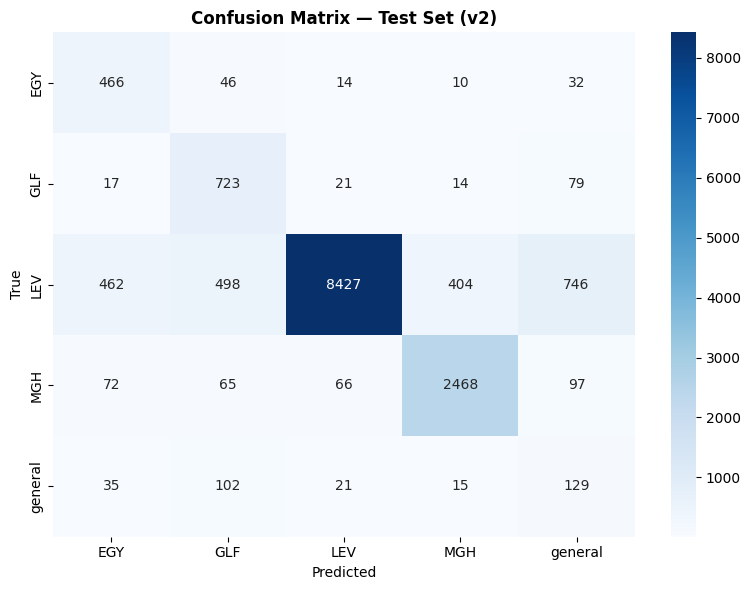

In [66]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix — Test Set (v2)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

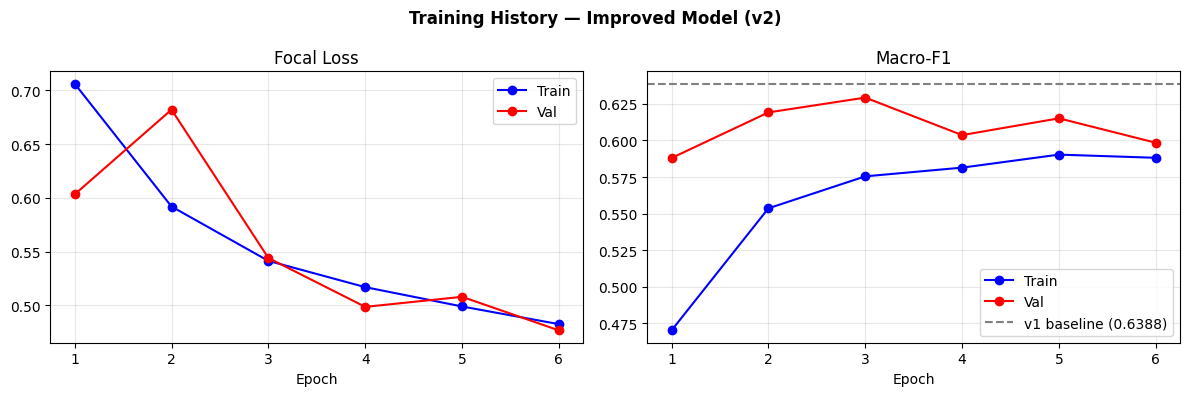

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_r = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_r, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs_r, history['val_loss'],   'r-o', label='Val')
ax1.set_title('Focal Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_r, history['train_f1'], 'b-o', label='Train')
ax2.plot(epochs_r, history['val_f1'],   'r-o', label='Val')
ax2.axhline(0.6388, color='gray', linestyle='--', label='v1 baseline (0.6388)')
ax2.set_title('Macro-F1'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Training History — Improved Model (v2)', fontweight='bold')
plt.tight_layout()
plt.show()

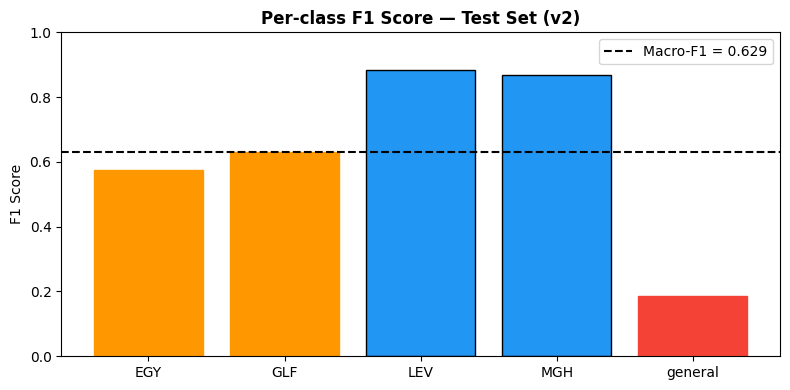


=== Per-class F1 comparison (v1 → v2) ===
  EGY     : 0.630 → 0.575  ↓ (-0.055)
  GLF     : 0.630 → 0.632  ↑ (+0.002)
  LEV     : 0.900 → 0.883  ↓ (-0.017)
  MGH     : 0.820 → 0.869  ↑ (+0.049)
  general : 0.220 → 0.186  ↓ (-0.034)


In [68]:
per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)

plt.figure(figsize=(8, 4))
bars = plt.bar(le.classes_, per_class_f1, color=['#2196F3']*5, edgecolor='black')
for cls_name, color in [('general', '#f44336'), ('EGY', '#FF9800'), ('GLF', '#FF9800')]:
    idx = list(le.classes_).index(cls_name)
    bars[idx].set_color(color)
plt.axhline(y=test_f1, color='black', linestyle='--', label=f'Macro-F1 = {test_f1:.3f}')
plt.title('Per-class F1 Score — Test Set (v2)', fontweight='bold')
plt.ylabel('F1 Score'); plt.ylim(0, 1.0)
plt.legend(); plt.tight_layout()
plt.show()

print("\n=== Per-class F1 comparison (v1 → v2) ===")
v1 = {'EGY': 0.63, 'GLF': 0.63, 'LEV': 0.90, 'MGH': 0.82, 'general': 0.22}
for cls, new_f1 in zip(le.classes_, per_class_f1):
    old_f1 = v1.get(cls, 0.0)
    arrow  = '↑' if new_f1 > old_f1 else ('↓' if new_f1 < old_f1 else '=')
    print(f"  {cls:8s}: {old_f1:.3f} → {new_f1:.3f}  {arrow} ({new_f1 - old_f1:+.3f})")

In [69]:
test_copy = test_df.reset_index(drop=True).copy()
test_copy['pred_label']  = test_preds
test_copy['pred_region'] = le.inverse_transform(test_preds)
test_copy['true_region'] = le.inverse_transform(test_labels)
test_copy['correct']     = test_copy['pred_label'] == test_copy['label']

errors = test_copy[~test_copy['correct']]
print(f"Total errors: {len(errors):,} / {len(test_copy):,} ({100*len(errors)/len(test_copy):.1f}%)\n")

print("=== Top confusion pairs ===")
pairs = errors.groupby(['true_region', 'pred_region']).size().sort_values(ascending=False)
print(pairs.head(10).to_string())

for true_cls in ['general', 'EGY', 'GLF']:
    subset = errors[errors['true_region'] == true_cls]
    n = min(3, len(subset))
    if n == 0:
        continue
    sample = subset.sample(n, random_state=42)
    print(f"\n--- {true_cls} misclassified as → ---")
    for _, row in sample.iterrows():
        print(f"  True: {row['true_region']:8s} → Predicted: {row['pred_region']}")
        print(f"  Text: {row['text_clean'][:100]}")
        print()

Total errors: 2,816 / 15,029 (18.7%)

=== Top confusion pairs ===
true_region  pred_region
LEV          general        746
             GLF            498
             EGY            462
             MGH            404
general      GLF            102
MGH          general         97
GLF          general         79
MGH          EGY             72
             LEV             66
             GLF             65

--- general misclassified as → ---
  True: general  → Predicted: GLF
  Text: يستاهل ابو نهار

  True: general  → Predicted: GLF
  Text: هالارهابيين يا جماعه الربع اذونا واذوا المسلمين وشوهوا صورتنا قدام العالم اجمع لا ويتحدون الانظمه وا

  True: general  → Predicted: EGY
  Text: كل كلمه موجوده في التقرير ده حقيقيه وتمثل الواقع الاليم ولاكن الطامه الكبري التي اغفلها التقرير هي ا


--- EGY misclassified as → ---
  True: EGY      → Predicted: GLF
  Text: جزاه الله علي قد نيته، وان شاء الله يعوضه احسن منها

  True: EGY      → Predicted: GLF
  Text: انا عايز حقي وكيل اعمال ذا اللاعب الض

=== Attention maps — misclassified 'general' examples ===


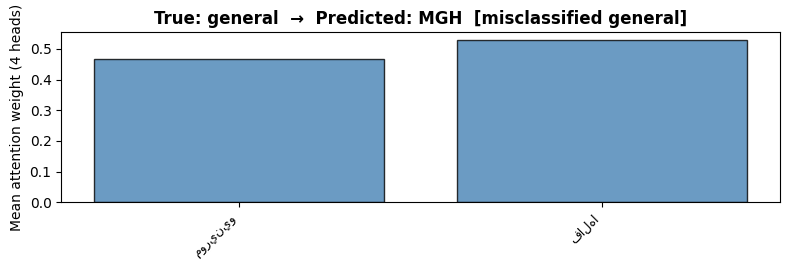

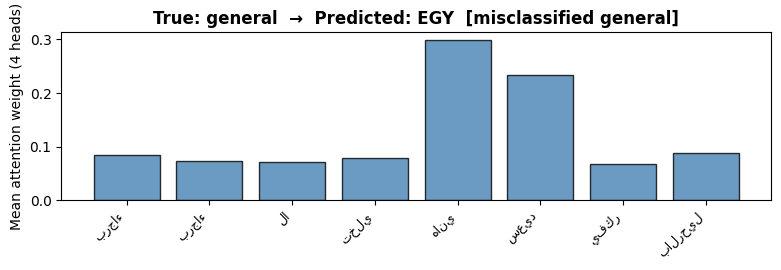

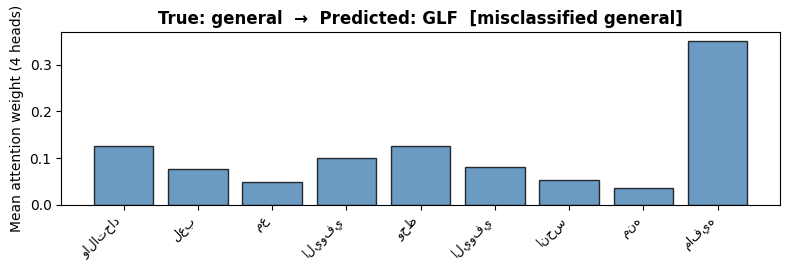


=== Attention maps — correctly classified examples ===


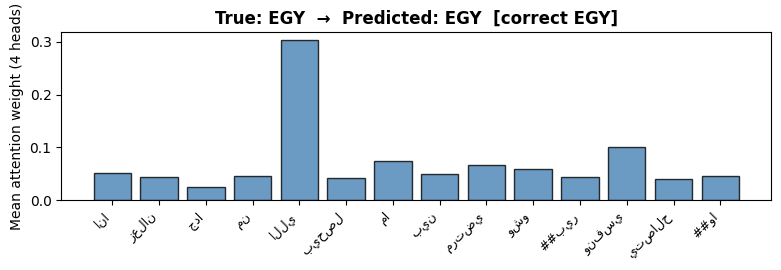

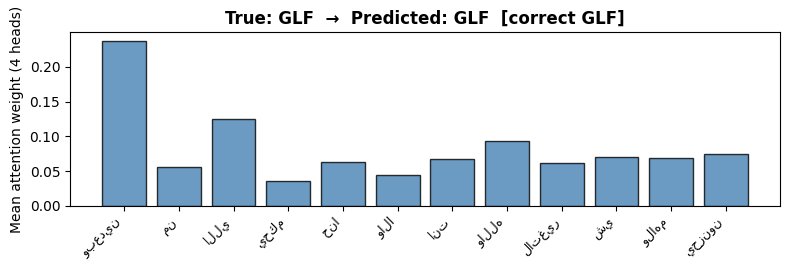

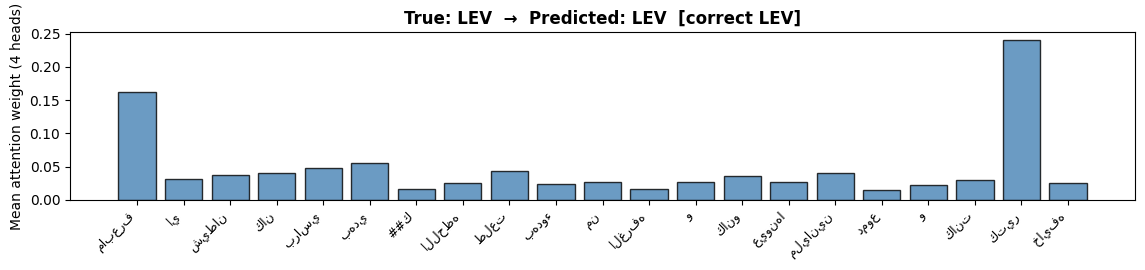

In [70]:
def show_attention(text, true_label, pred_label, title=""):
    """Visualise mean multi-head attention weights for one sentence."""
    model.eval()
    enc = tokenizer(text, max_length=MAX_LEN, padding='max_length',
                    truncation=True, return_tensors='pt')
    input_ids      = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)
    with torch.no_grad():
        logits, alpha = model(input_ids, attention_mask)

    tokens   = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    real_len = int(attention_mask[0].cpu().sum())
    tokens   = tokens[1:real_len - 1]
    weights  = alpha[0].cpu().numpy()[1:real_len - 1]

    plt.figure(figsize=(max(8, len(tokens) * 0.55), 2.8))
    plt.bar(range(len(tokens)), weights, color='steelblue', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right', fontsize=9)
    plt.title(
        f'True: {true_label}  →  Predicted: {pred_label}'
        + (f'  [{title}]' if title else ''),
        fontweight='bold'
    )
    plt.ylabel('Mean attention weight (4 heads)')
    plt.tight_layout()
    plt.show()

# Misclassified 'general' examples
print("=== Attention maps — misclassified 'general' examples ===")
gen_errors = errors[errors['true_region'] == 'general'].head(3)
for _, row in gen_errors.iterrows():
    show_attention(row['text_clean'], row['true_region'], row['pred_region'],
                   title='misclassified general')

# Correctly classified examples
print("\n=== Attention maps — correctly classified examples ===")
for region in ['EGY', 'GLF', 'LEV']:
    correct = test_copy[(test_copy['correct']) & (test_copy['true_region'] == region)]
    if len(correct) == 0:
        continue
    row = correct.sample(1, random_state=42).iloc[0]
    show_attention(row['text_clean'], row['true_region'], row['pred_region'],
                   title=f'correct {region}')